# Data Loading & Merging
**Goal:** Load both datasets, inspect them, clean the minimum required for a successful merge, and produce a single analysis-ready DataFrame saved to `data/processed/`.

**Datasets:**
- `data/raw/fear_greed_index.csv` — Bitcoin Fear & Greed Index (daily)
- `data/raw/historical_data.csv` — Hyperliquid historical trade fills

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

In [4]:
RAW_DIR       = '../data/raw/'
PROCESSED_DIR = '../data/processed/'
os.makedirs(PROCESSED_DIR, exist_ok=True)

FG_FILE     = os.path.join(RAW_DIR, 'fear_greed_index.csv')      
TRADER_FILE = os.path.join(RAW_DIR, 'historical_data.csv')

In [5]:
fg_raw = pd.read_csv(FG_FILE)
print(f'Shape : {fg_raw.shape}')
print(f'Columns: {fg_raw.columns.tolist()}')
fg_raw.head()

Shape : (2644, 4)
Columns: ['timestamp', 'value', 'classification', 'date']


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [6]:
fg_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


In [7]:
print("missing values")
print(fg_raw.isnull().sum())

missing values
timestamp         0
value             0
classification    0
date              0
dtype: int64


In [8]:
fg = fg_raw.copy()

# Parse date column->datetime
fg['date'] = pd.to_datetime(fg['date'], infer_datetime_format=True)

# Normalise column names
fg.rename(columns={'value': 'fg_value', 'classification': 'fg_label'}, inplace=True)

# Drop redundant timestamp column
fg.drop(columns=['timestamp'], inplace=True, errors='ignore')

# Encode sentiment as ordered category
sentiment_order = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']
fg['fg_label'] = pd.Categorical(fg['fg_label'], categories=sentiment_order, ordered=True)

fg.sort_values('date', inplace=True)
fg.reset_index(drop=True, inplace=True)

print(f'Date range : {fg.date.min().date()} → {fg.date.max().date()}')
print(f'Total days : {len(fg)}')
print(f'Label distribution:\n{fg.fg_label.value_counts()}')
fg.head()

Date range : 2018-02-01 → 2025-05-02
Total days : 2644
Label distribution:
fg_label
Fear             781
Greed            633
Extreme Fear     508
Neutral          396
Extreme Greed    326
Name: count, dtype: int64


C:\Users\iamli\AppData\Local\Temp\ipykernel_23524\1055315869.py:4: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  fg['date'] = pd.to_datetime(fg['date'], infer_datetime_format=True)


,fg_value,fg_label,date
0,30,Fear,2018-02-01
1,15,Extreme Fear,2018-02-02
2,40,Fear,2018-02-03
3,24,Extreme Fear,2018-02-04
4,11,Extreme Fear,2018-02-05


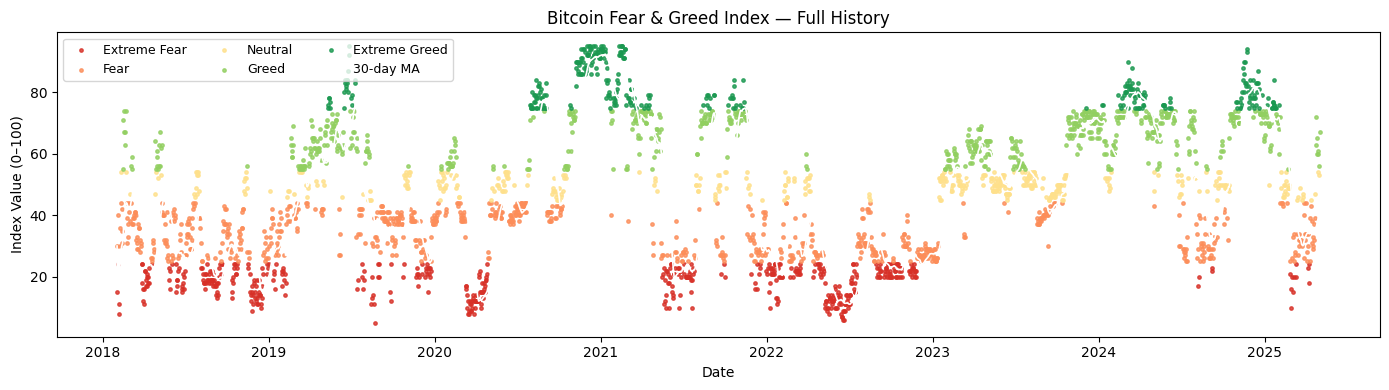

In [9]:
fig, ax = plt.subplots(figsize=(14, 4))

# Colour-code
color_map = {
    'Extreme Fear': '#d73027',
    'Fear'        : '#fc8d59',
    'Neutral'     : '#fee08b',
    'Greed'       : '#91cf60',
    'Extreme Greed': '#1a9850'
}

for label, grp in fg.groupby('fg_label', observed=True):
    ax.scatter(grp['date'], grp['fg_value'],
               label=label, color=color_map[label], s=6, alpha=0.8)

# Rolling 30-day average
fg_sorted = fg.sort_values('date')
rolling = fg_sorted['fg_value'].rolling(30, min_periods=1).mean()
ax.plot(fg_sorted['date'], rolling, color='white', linewidth=1.2, label='30-day MA')

ax.set(title='Bitcoin Fear & Greed Index — Full History',
       xlabel='Date', ylabel='Index Value (0–100)')
ax.legend(loc='upper left', fontsize=9, ncol=3)
plt.tight_layout()
plt.show()

In [10]:
tr_raw = pd.read_csv(TRADER_FILE)
print(f'Shape : {tr_raw.shape}')
print(f'Columns: {tr_raw.columns.tolist()}')
tr_raw.head()

Shape : (211224, 16)
Columns: ['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp']


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [11]:
tr_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

In [12]:
print('Missing values:')
print(tr_raw.isnull().sum())

Missing values:
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64


In [13]:
tr = tr_raw.copy()

# Normalise column names to snake_case 
tr.columns = (
    tr.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_', regex=False)
)

# Parse timestamp (format: DD-MM-YYYY HH:MM  IST)
tr['timestamp_ist'] = pd.to_datetime(
    tr['timestamp_ist'], format='%d-%m-%Y %H:%M', errors='coerce'
)

# Extract plain date for merging
tr['date'] = tr['timestamp_ist'].dt.normalize()    
tr['date'] = pd.to_datetime(tr['date'])

#  Numeric coercion 
numeric_cols = ['execution_price', 'size_tokens', 'size_usd',
                'closed_pnl', 'fee']
for col in numeric_cols:
    if col in tr.columns:
        tr[col] = pd.to_numeric(tr[col], errors='coerce')

# Drop rows with unparseable timestamps
bad_ts = tr['timestamp_ist'].isna().sum()
print(f'Rows dropped due to bad timestamp: {bad_ts}')
tr.dropna(subset=['timestamp_ist'], inplace=True)

# Standardise side column
tr['side'] = tr['side'].str.strip().str.upper()  

print(f'\nShape after cleaning : {tr.shape}')
print(f'Date range           : {tr.date.min().date()} → {tr.date.max().date()}')
print(f'Unique accounts      : {tr.account.nunique()}')
print(f'Unique coins         : {tr.coin.nunique()}')
tr.head()

Rows dropped due to bad timestamp: 0

Shape after cleaning : (211224, 17)
Date range           : 2023-05-01 → 2025-05-01
Unique accounts      : 32
Unique coins         : 246


,account,coin,execution_price,size_tokens,size_usd,side,timestamp_ist,start_position,direction,closed_pnl,transaction_hash,order_id,crossed,fee,trade_id,timestamp,date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02


In [14]:
daily_trader = (
    tr.groupby(['account', 'date'])
    .agg(
        total_pnl      = ('closed_pnl',      'sum'),
        total_volume   = ('size_usd',         'sum'),
        total_fee      = ('fee',              'sum'),
        trade_count    = ('trade_id',         'count'),
        buy_count      = ('side', lambda x: (x == 'BUY').sum()),
        sell_count     = ('side', lambda x: (x == 'SELL').sum()),
        avg_exec_price = ('execution_price',  'mean'),
        coins_traded   = ('coin',             'nunique'),
    )
    .reset_index()
)

# Net PnL after fees
daily_trader['net_pnl'] = daily_trader['total_pnl'] - daily_trader['total_fee']

# Buy ratio (directional bias)
daily_trader['buy_ratio'] = (
    daily_trader['buy_count'] /
    (daily_trader['buy_count'] + daily_trader['sell_count'])
).round(4)

print(f'Daily trader summary shape: {daily_trader.shape}')
daily_trader.head(10)

Daily trader summary shape: (2341, 12)


,account,date,total_pnl,total_volume,total_fee,trade_count,buy_count,sell_count,avg_exec_price,coins_traded,net_pnl,buy_ratio
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.000000,900880.13,167.796055,177,0,177,3204.461017,1,-167.796055,0.0000
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0.000000,542413.18,67.883615,68,0,68,653.365147,2,-67.883615,0.0000
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,0.000000,949380.00,94.937983,40,0,40,3164.600000,1,-94.937983,0.0000
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,-21227.000000,338240.00,33.823995,12,12,0,3382.400000,1,-21260.823995,1.0000
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,1603.100000,465700.00,104.622490,27,12,15,232.921111,1,1498.477510,0.4444
5,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-28,-132271.000000,1316799.98,131.679967,82,82,0,2691.556585,2,-132402.679967,1.0000
6,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-30,0.000000,1116918.77,390.921553,23,0,23,3723.017391,1,-390.921553,0.0000
7,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-12-06,-175611.000056,1212299.96,121.229992,33,33,0,4041.000000,1,-175732.230048,1.0000
8,0x083384f897ee0f19899168e3b1bec365f52a9012,2025-01-19,71393.964098,5306093.62,780.336440,465,112,353,741.062796,2,70613.627658,0.2409
9,0x083384f897ee0f19899168e3b1bec365f52a9012,2025-01-20,40218.599998,479429.99,23.971493,51,28,23,239.154706,1,40194.628505,0.5490


In [15]:
# check overlap
trader_dates   = set(daily_trader['date'].dt.date)
sentiment_dates = set(fg['date'].dt.date)
overlap = trader_dates & sentiment_dates

print(f'Trader date range    : {min(trader_dates)} → {max(trader_dates)}')
print(f'Sentiment date range : {min(sentiment_dates)} → {max(sentiment_dates)}')
print(f'Overlapping dates    : {len(overlap)}')
print(f'Trader dates with NO sentiment match: {len(trader_dates - sentiment_dates)}')

Trader date range    : 2023-05-01 → 2025-05-01
Sentiment date range : 2018-02-01 → 2025-05-02
Overlapping dates    : 479
Trader dates with NO sentiment match: 1


In [16]:
# Merge on date (left join keeps all trader rows)
merged = daily_trader.merge(
    fg[['date', 'fg_value', 'fg_label']],
    on='date',
    how='left'
)

# Report any unmatched rows
unmatched = merged['fg_value'].isna().sum()
print(f'Rows without sentiment match : {unmatched} '
      f'({unmatched/len(merged)*100:.1f}%)')

print(f'\nFinal merged shape: {merged.shape}')
merged.head()

Rows without sentiment match : 1 (0.0%)

Final merged shape: (2341, 14)


,account,date,total_pnl,total_volume,total_fee,trade_count,buy_count,sell_count,avg_exec_price,coins_traded,net_pnl,buy_ratio,fg_value,fg_label
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.0,900880.13,167.796055,177,0,177,3204.461017,1,-167.796055,0.0000,76.0,Extreme Greed
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0.0,542413.18,67.883615,68,0,68,653.365147,2,-67.883615,0.0000,90.0,Extreme Greed
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,0.0,949380.00,94.937983,40,0,40,3164.600000,1,-94.937983,0.0000,83.0,Extreme Greed
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,-21227.0,338240.00,33.823995,12,12,0,3382.400000,1,-21260.823995,1.0000,94.0,Extreme Greed
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,1603.1,465700.00,104.622490,27,12,15,232.921111,1,1498.477510,0.4444,79.0,Extreme Greed


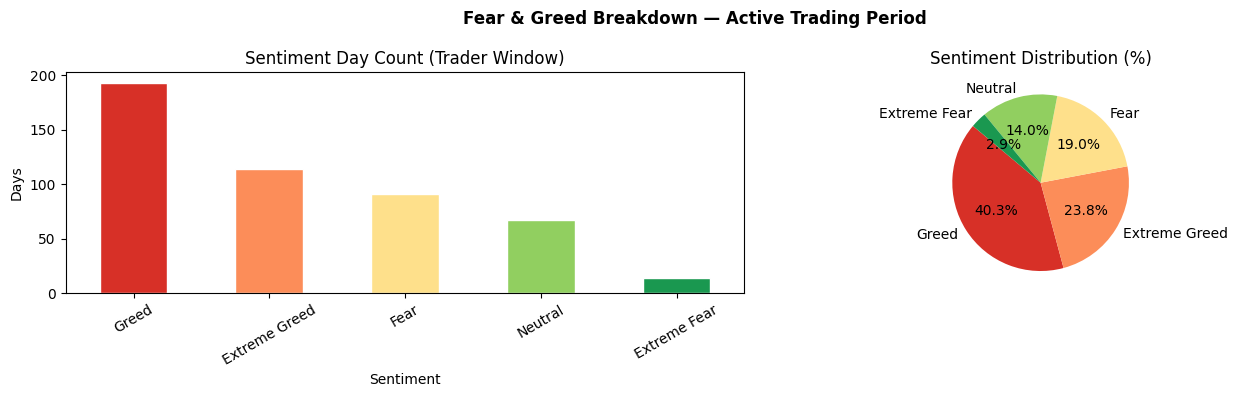

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

label_counts = merged.drop_duplicates('date')['fg_label'].value_counts()
colors = ['#d73027','#fc8d59','#fee08b','#91cf60','#1a9850']

# Bar chart
label_counts.plot(kind='bar', ax=axes[0], color=colors[:len(label_counts)],
                  edgecolor='white')
axes[0].set(title='Sentiment Day Count (Trader Window)',
            xlabel='Sentiment', ylabel='Days')
axes[0].tick_params(axis='x', rotation=30)

# Pie chart
label_counts.plot(kind='pie', ax=axes[1], colors=colors[:len(label_counts)],
                  autopct='%1.1f%%', startangle=140, legend=False)
axes[1].set(title='Sentiment Distribution (%)', ylabel='')

plt.suptitle('Fear & Greed Breakdown — Active Trading Period', fontweight='bold')
plt.tight_layout()
plt.show()

In [18]:
print('Final Merged DataFrame Schema')
print(merged.dtypes)
print(f'\nShape  : {merged.shape}')
print(f'Columns: {merged.columns.tolist()}')

Final Merged DataFrame Schema
account                   object
date              datetime64[ns]
total_pnl                float64
total_volume             float64
total_fee                float64
trade_count                int64
buy_count                  int64
sell_count                 int64
avg_exec_price           float64
coins_traded               int64
net_pnl                  float64
buy_ratio                float64
fg_value                 float64
fg_label                category
dtype: object

Shape  : (2341, 14)
Columns: ['account', 'date', 'total_pnl', 'total_volume', 'total_fee', 'trade_count', 'buy_count', 'sell_count', 'avg_exec_price', 'coins_traded', 'net_pnl', 'buy_ratio', 'fg_value', 'fg_label']


In [19]:
print('Descriptive Statistics')
merged[['total_pnl','net_pnl','total_volume','trade_count',
        'buy_ratio','fg_value']].describe().round(2)

Descriptive Statistics


,total_pnl,net_pnl,total_volume,trade_count,buy_ratio,fg_value
count,2341.00,2341.00,2341.00,2341.00,2341.00,2340.00
mean,4398.53,4293.51,508837.01,90.23,0.49,54.85
std,28415.94,28352.29,2413745.03,214.61,0.36,20.62
min,-358963.14,-359574.55,0.00,1.00,0.00,10.00
25%,0.00,-3.33,15764.01,9.00,0.14,34.00
50%,207.98,179.12,69357.39,29.00,0.49,55.00
75%,1842.84,1740.96,250781.18,80.00,0.83,74.00
max,533974.66,533706.37,51250451.44,4083.00,1.00,94.00


In [20]:
# Save processed files
merged.to_csv(os.path.join(PROCESSED_DIR, 'merged_daily.csv'), index=False)
fg.to_csv(os.path.join(PROCESSED_DIR, 'fear_greed_clean.csv'), index=False)
daily_trader.to_csv(os.path.join(PROCESSED_DIR, 'daily_trader_agg.csv'), index=False)

print('Saved to data/processed/')

Saved to data/processed/
